# Analyse de polysémie — 20 mots français
Analyse sur 10 mots polysémiques et 10 mots monosémiques avec CamemBERT.

In [1]:
%run polybert_functions.ipynb

/home/salmach/.local/share/uv/tools/jupyterlab/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█████████████████████████████████████████████| 199/199 [00:00<00:00, 4434.05it/s]
[transformers] CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modèle chargé : camembert-base


In [2]:
mots_polysemique = ["café", "souris", "langue", "fraise", "avocat",
                    "bois", "livre", "vol", "action", "tour"]

mots_monosemique = ["médecin", "volcan", "pentathlon", "atome", "photosynthèse",
                    "chrysanthème", "hydrogène", "électron", "antibiotique", "alambic"]

mots_cible = mots_polysemique + mots_monosemique
print(f"{len(mots_cible)} mots : {len(mots_polysemique)} polysémiques, {len(mots_monosemique)} monosémiques")

20 mots : 10 polysémiques, 10 monosémiques


In [3]:
articles_par_mot = {
    # Polysémiques
    "café":           ["Café", "Café (boisson)", "Café (établissement)"],
    "souris":         ["Souris", "Souris (informatique)"],
    "langue":         ["Langue", "Langue (anatomie)", "Langue vivante", "Linguistique"],
    "fraise":         ["Fraise", "Fraise (outil)", "Fraise (costume)"],
    "avocat":         ["Avocat (fruit)", "Avocat (métier)"],
    "bois":           ["Bois", "Bois (matériau)", "Bois (anatomie)"],
    "livre":          ["Livre (document)", "Livre (unité de masse)", "Livre sterling"],
    "vol":            ["Vol (aviation)", "Vol (droit)", "Migration des oiseaux"],
    "action":         ["Action (finance)", "Action (philosophie)", "Action (droit)", "Cinéma"],
    "tour":           ["Tour (architecture)", "Tour (machine-outil)",
                       "Tour de France", "Tour de magie", "Tournée"],
    # Monosémiques
    "médecin":        ["Médecin"],
    "volcan":         ["Volcan", "Éruption volcanique"],
    "pentathlon":     ["Pentathlon", "Pentathlon moderne"],
    "atome":          ["Atome"],
    "photosynthèse":  ["Photosynthèse"],
    "chrysanthème":   ["Chrysanthème"],
    "hydrogène":      ["Hydrogène"],
    "électron":       ["Électron"],
    "antibiotique":   ["Antibiotique"],
    "alambic":        ["Alambic"],
}

In [4]:
corpus = build_corpus(articles_par_mot)

café                : 60 phrases
souris              : 60 phrases
langue              : 87 phrases
fraise              : 90 phrases
avocat              : 57 phrases
bois                : 30 phrases
livre               : 90 phrases
vol                 : 38 phrases
action              : 40 phrases
tour                : 84 phrases
médecin             : 15 phrases
volcan              : 42 phrases
pentathlon          : 34 phrases
atome               : 30 phrases
photosynthèse       : 30 phrases
chrysanthème        : 12 phrases
hydrogène           : 30 phrases
électron            : 30 phrases
antibiotique        : 30 phrases
alambic             : 8 phrases


In [5]:
embeddings, phrases_retenues = extract_embeddings(corpus)

café                : 54 embeddings
souris              : 56 embeddings
langue              : 76 embeddings
fraise              : 79 embeddings
avocat              : 47 embeddings
bois                : 26 embeddings
livre               : 83 embeddings
vol                 : 31 embeddings
action              : 28 embeddings
tour                : 76 embeddings
médecin             : 14 embeddings
volcan              : 35 embeddings
pentathlon          : 29 embeddings
atome               : 24 embeddings
photosynthèse       : 24 embeddings
chrysanthème        : 12 embeddings
hydrogène           : 28 embeddings
électron            : 23 embeddings
antibiotique        : 27 embeddings
alambic             : 8 embeddings


In [6]:
df_scores = compute_scores_df(embeddings, mots_polysemique=mots_polysemique)
print(df_scores.to_string(index=False))

          mot  score_polysemie  sim_moyenne  n_embeddings        type
         tour         0.163028     0.664545            76 polysémique
         bois         0.151974     0.783000            26 polysémique
       avocat         0.150639     0.717648            47 polysémique
    hydrogène         0.150541     0.790951            28 monosémique
        livre         0.143664     0.735389            83 polysémique
       volcan         0.141316     0.839767            35 monosémique
       souris         0.138082     0.709320            56 polysémique
       action         0.134978     0.735117            28 polysémique
       langue         0.128681     0.736779            76 polysémique
      médecin         0.114098     0.770012            14 monosémique
        atome         0.107675     0.780794            24 monosémique
          vol         0.107268     0.765802            31 polysémique
         café         0.101144     0.801711            54 polysémique
   pentathlon       

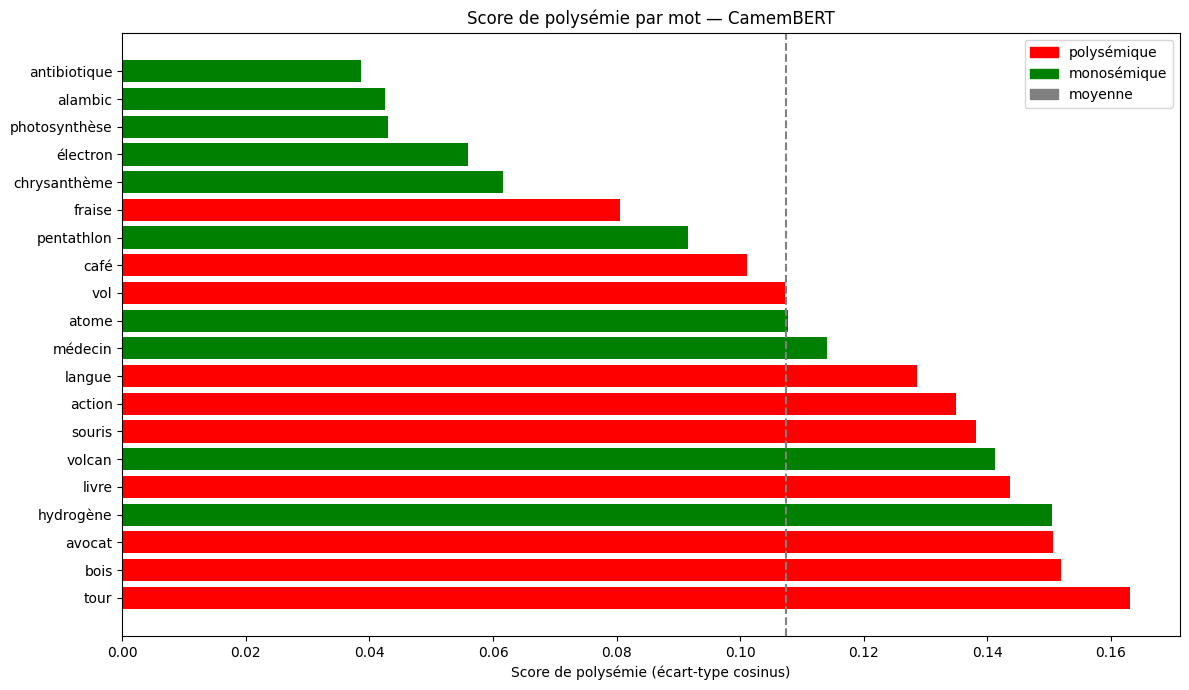

In [7]:
viz_bar_scores(
    df_scores,
    titre="Score de polysémie par mot — CamemBERT",
    fichier="score_polysemie.png"
)

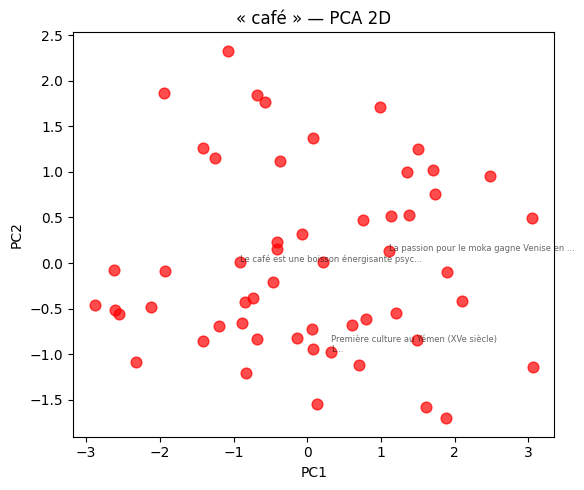

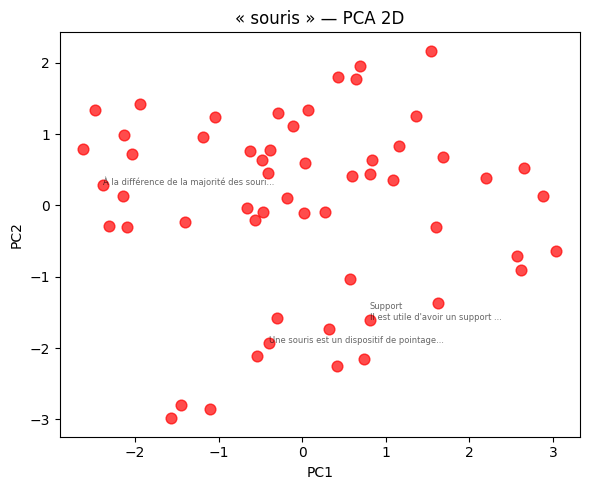

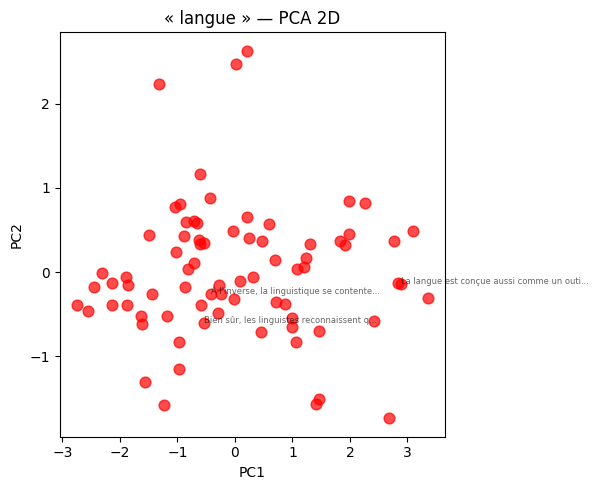

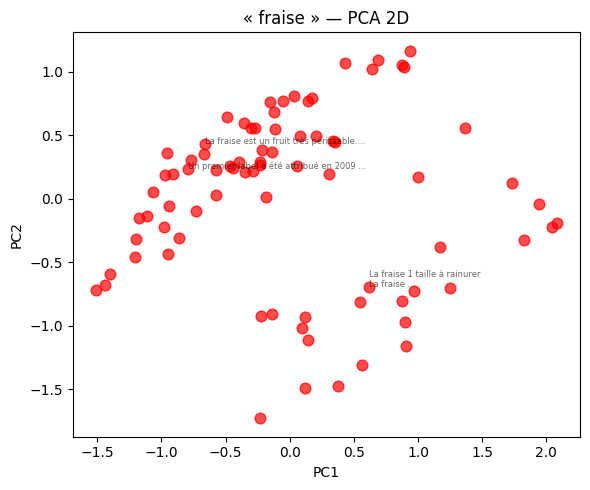

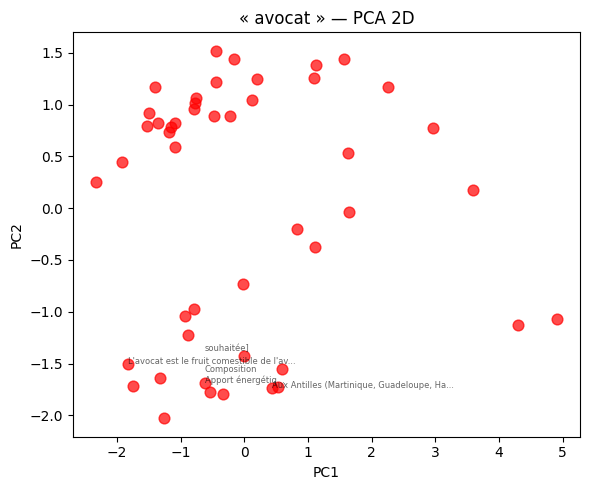

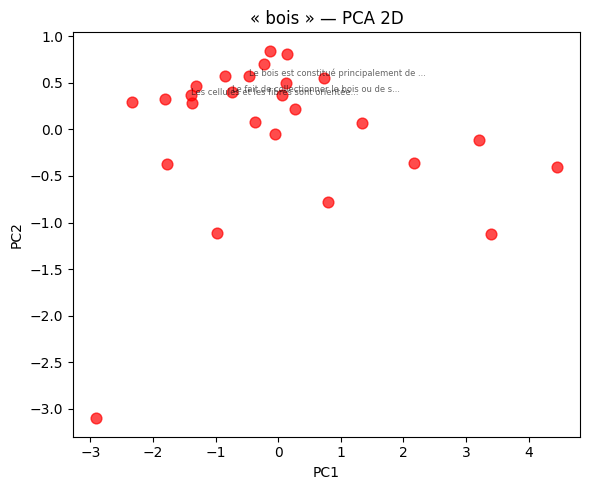

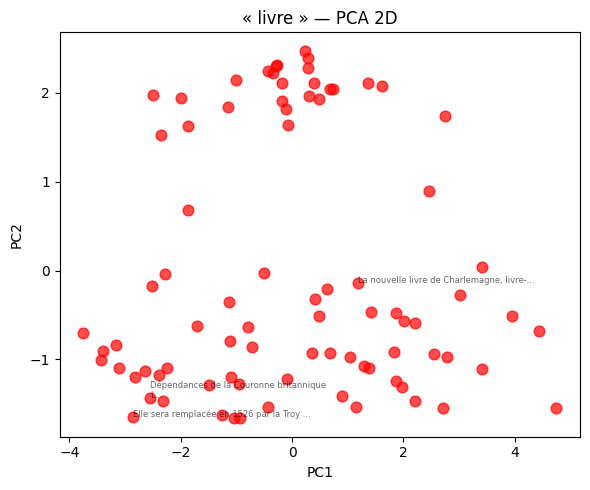

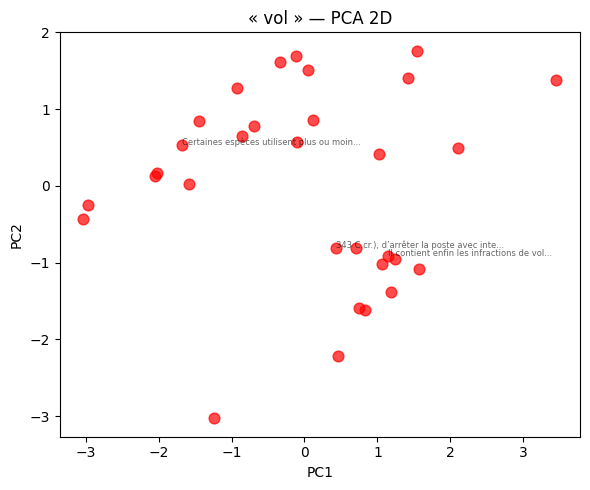

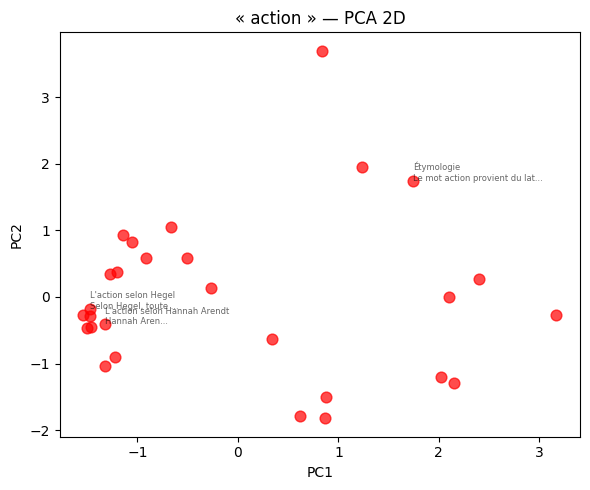

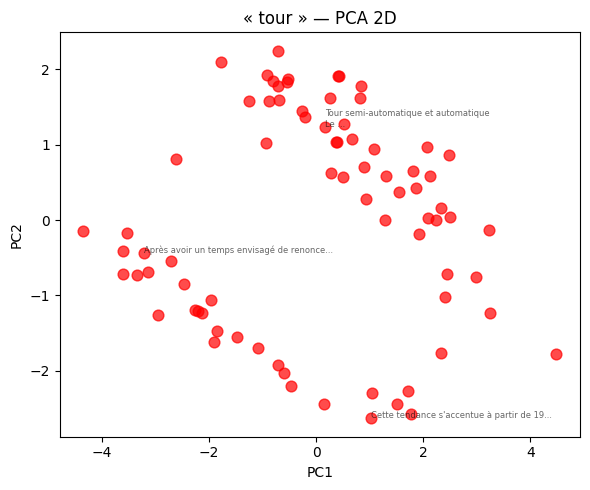

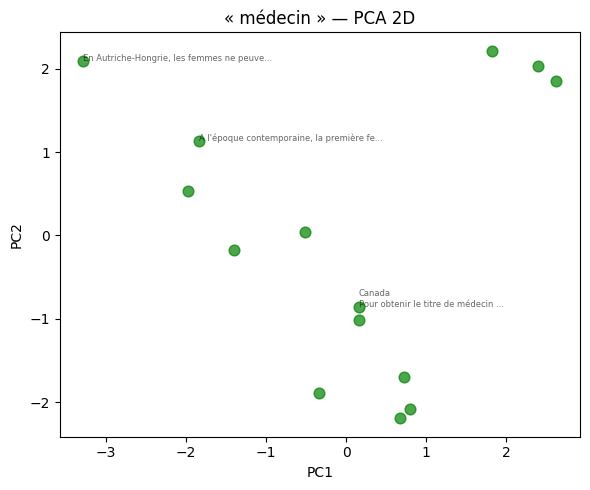

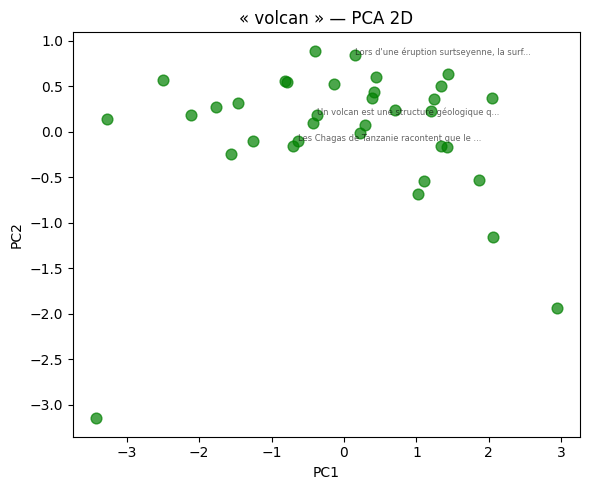

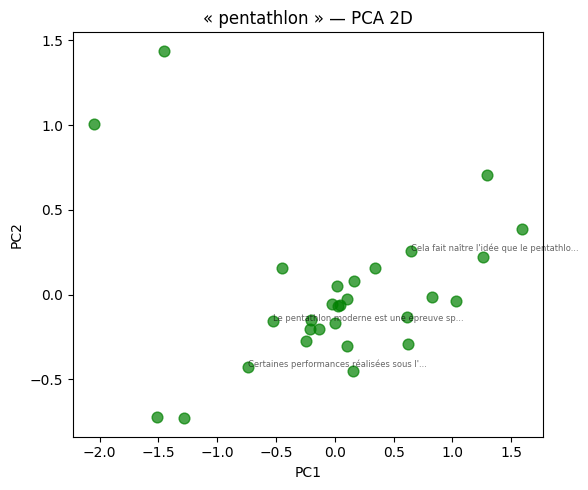

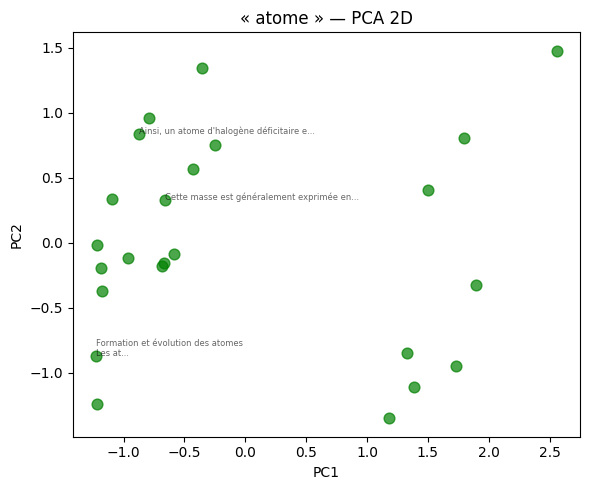

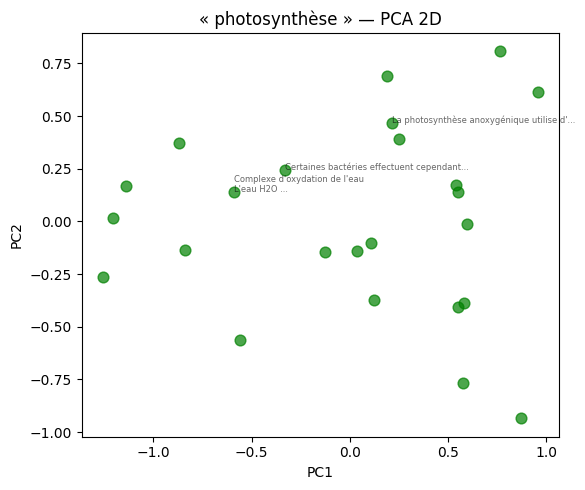

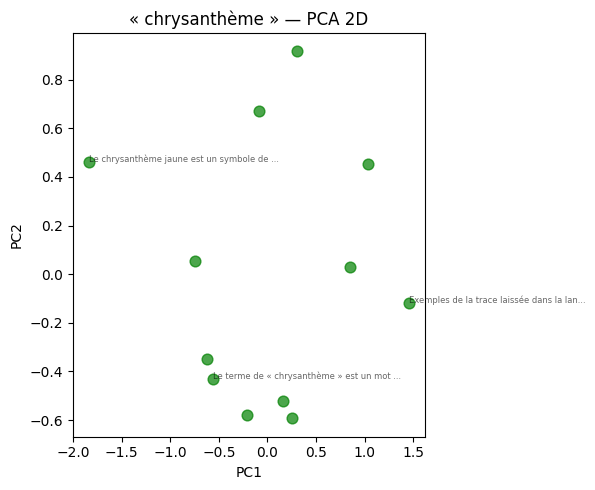

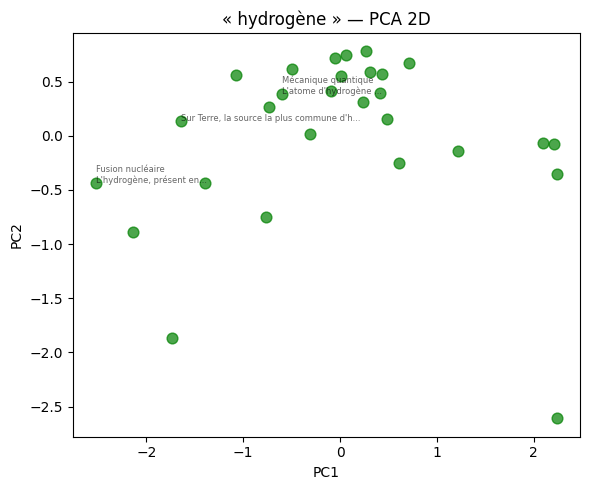

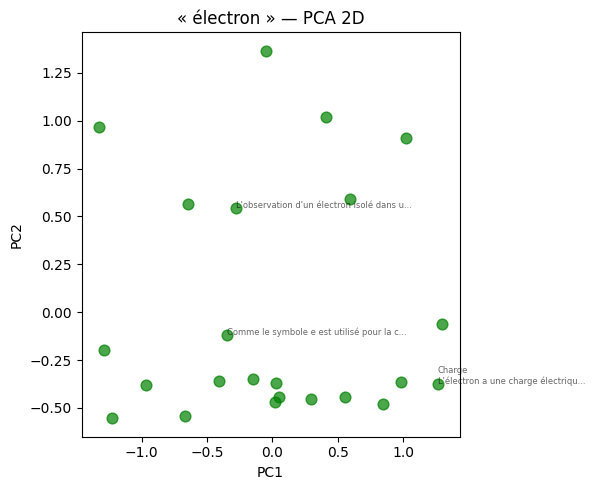

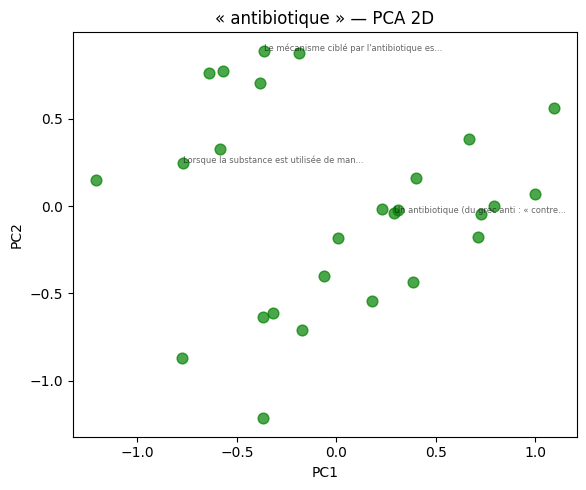

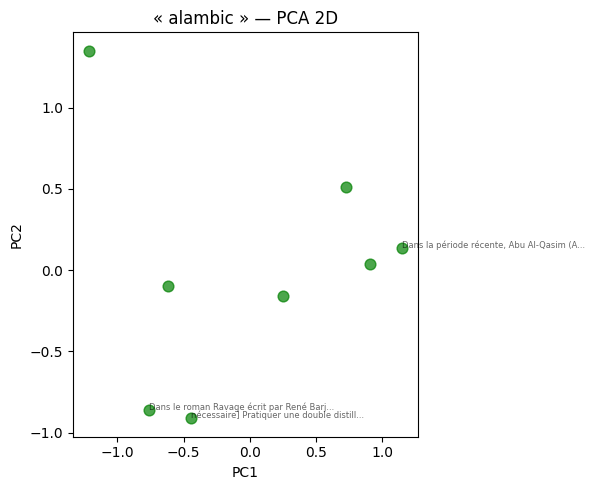

In [8]:
for mot in mots_cible:
    viz_mot_pca(mot, embeddings, phrases_retenues, mots_polysemique=mots_polysemique)

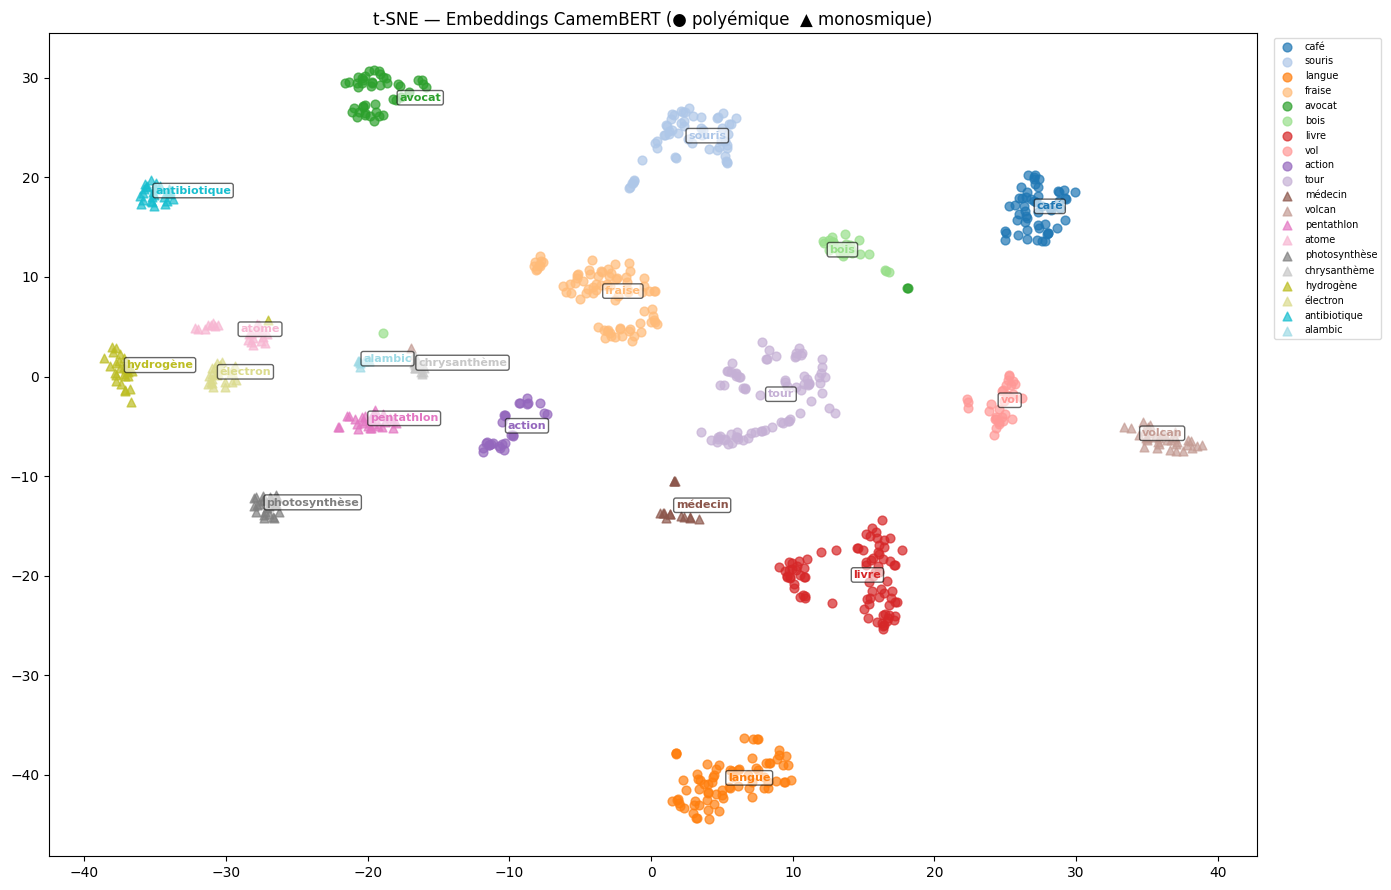

In [9]:
viz_tsne_global(embeddings, mots_polysemique=mots_polysemique, fichier="tsne_global.png")

Spearman ρ=0.623 (p=0.0033)  |  Pearson r=0.631 (p=0.0028)


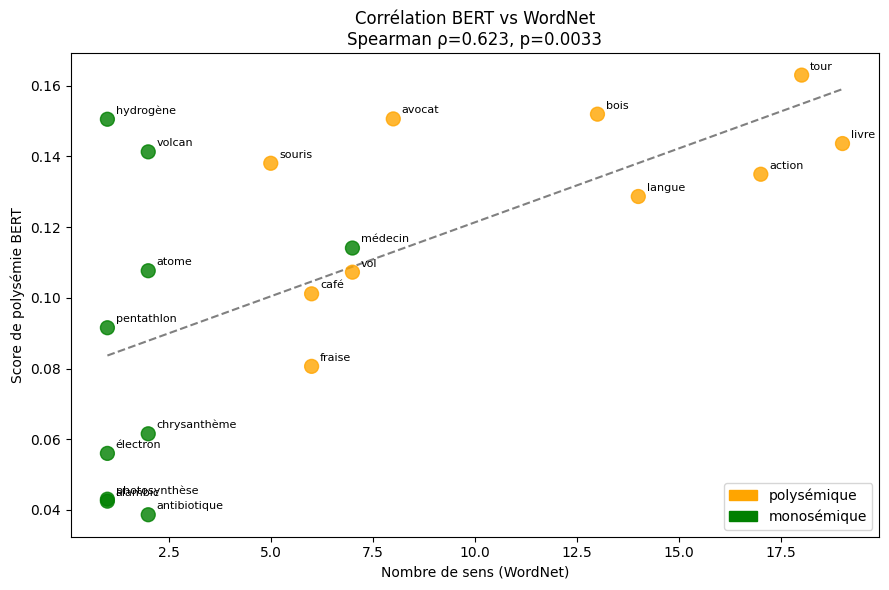

          mot  score_polysemie  nb_sens        type
         tour         0.163028       18 polysémique
         bois         0.151974       13 polysémique
       avocat         0.150639        8 polysémique
    hydrogène         0.150541        1 monosémique
        livre         0.143664       19 polysémique
       volcan         0.141316        2 monosémique
       souris         0.138082        5 polysémique
       action         0.134978       17 polysémique
       langue         0.128681       14 polysémique
      médecin         0.114098        7 monosémique
        atome         0.107675        2 monosémique
          vol         0.107268        7 polysémique
         café         0.101144        6 polysémique
   pentathlon         0.091545        1 monosémique
       fraise         0.080617        6 polysémique
 chrysanthème         0.061539        2 monosémique
     électron         0.055990        1 monosémique
photosynthèse         0.043033        1 monosémique
      alambi

In [10]:
df_corr = viz_correlation_wordnet(df_scores, fichier="correlation_wordnet.png")
print(df_corr[["mot", "score_polysemie", "nb_sens", "type"]].to_string(index=False))